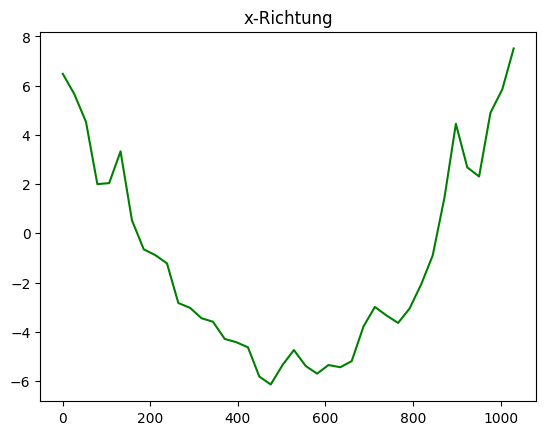

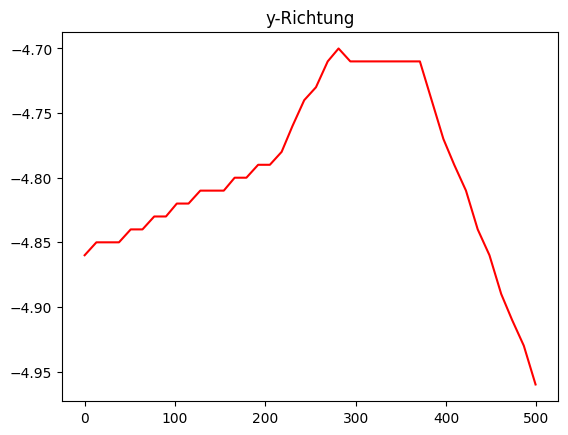

xAchse:
 Mittelpunkt = (513.6127046323256,10096.90022085221)
 Radius = 10102.605939621899

yAchse:
 Mittelpunkt = (251.8252447945881,-123758.3635393651)
 Radius = 123753.6543937084

[1, -1]
in X-Richtung sind wir 1 gekrümmt
in Y-Richtung sind wir -1 gekrümmt


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

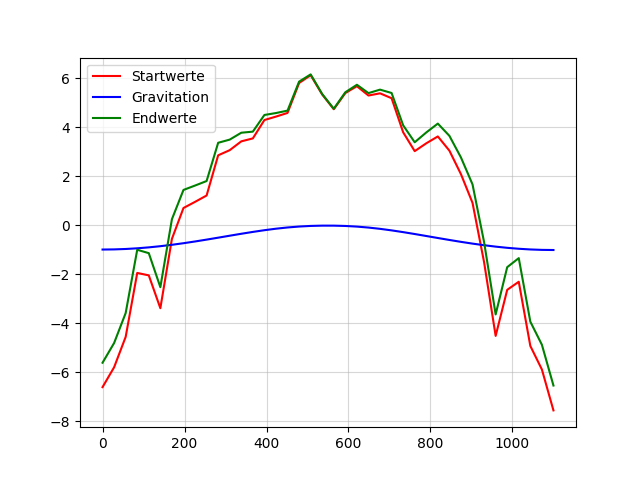

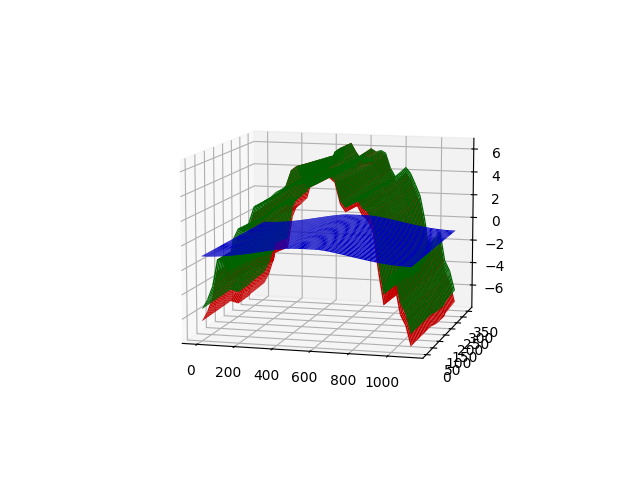

In [ ]:
import import_ipynb
import numpy as np
import xyzFile_zusammenrechnen_EW

import xy_KruemmungAnalyse
# def Auflager_gemessen(step,filename_MW,tol):
# def Auflager_generiert(l,b,step,tol):
import xyzFile_GRAVITATION_Kruemmung
# def gravitationsEinfluss_Auflager(l,b,t,step,auflager_liste,radius):

l = 1100
b = 360
t = 3.6
step = 40
tol = 10e-11
r = 35 # mm    # Radius der Auflager

# MESSWERTE echt
filename_MW = f"{t}mm_messwerte.xyz"
data_messwerte = np.loadtxt(filename_MW)

AuflagerOrte = xy_KruemmungAnalyse.Auflager_gemessen(step,filename_MW,tol)

# STARTWERTE
# filename_SW = f"{t}mm_startwerte.xyz"
# data_messwerte = np.loadtxt(filename_SW)

# AuflagerOrte = xy_KruemmungAnalyse.Auflager_gemessen(step,filename_SW,tol)

print(f"in X-Richtung sind wir {AuflagerOrte[0]} gekrümmt")
print(f"in Y-Richtung sind wir {AuflagerOrte[1]} gekrümmt")

xKruemmung = AuflagerOrte[0]
yKruemmung = AuflagerOrte[1]

if xKruemmung >= 0:
    x1 = l/2
    x2 = l/2
elif xKruemmung < 0:
    x1 = 0
    x2 = l
else:
    print("soll ma da kantenauflager machen?")
    #TODO Kantenauflager?

if yKruemmung >= 0:
    y1 = b/2
    y2 = b/2
elif yKruemmung < 0:
    y1 = 0
    y2 = b
else:
    print("soll ma da kantenauflager machen?")
    #TODO Kantenauflager?


auflager_liste = [(x1+r,y1+r),(x1+r,y2-r),(x2-r,y2-r),(x2-r,y1+r)]
#auflager_liste = [(radius,radius),(l-radius,b-radius),(radius,b-radius),(l-radius,radius)]


filename_GRAV = xyzFile_GRAVITATION_Kruemmung.gravitationsEinfluss_Auflager(l,b,t,step,auflager_liste,r)

xyzFile_zusammenrechnen_EW.plotten(l,b,t,step,filename_MW,filename_GRAV)
